1. Importar Librerías Necesarias

In [12]:
# Importamos las librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

2. Cargar los Datos

In [13]:
# Cargamos los datos desde los archivos CSV
data1 = pd.read_csv('../data/raw/airline_satisfaction_part1.csv')
data2 = pd.read_csv('../data/raw/airline_satisfaction_part2.csv')

# Combinamos los dos DataFrames en uno solo
data = pd.concat([data1, data2], ignore_index=True)

3. Inspeccionar los Datos

In [26]:
# Mostramos las primeras filas del DataFrame combinado para tener una vista preliminar de los datos
data.head()

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,19556,Female,Loyal Customer,52,Business travel,Eco,160,5,4,...,5,5,5,5,2,5,5,50,44.0,satisfied
1,1,90035,Female,Loyal Customer,36,Business travel,Business,2863,1,1,...,4,4,4,4,3,4,5,0,0.0,satisfied
2,2,12360,Male,disloyal Customer,20,Business travel,Eco,192,2,0,...,2,4,1,3,2,2,2,0,0.0,neutral or dissatisfied
3,3,77959,Male,Loyal Customer,44,Business travel,Business,3377,0,0,...,1,1,1,1,3,1,4,0,6.0,satisfied
4,4,36875,Female,Loyal Customer,49,Business travel,Eco,1182,2,3,...,2,2,2,2,4,2,4,0,20.0,satisfied


In [27]:
# Obtenemos información general del DataFrame, incluyendo el tipo de datos y la cantidad de valores no nulos por columnas
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 25 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Unnamed: 0                         129880 non-null  int64  
 1   id                                 129880 non-null  int64  
 2   Gender                             129880 non-null  object 
 3   Customer Type                      129880 non-null  object 
 4   Age                                129880 non-null  int64  
 5   Type of Travel                     129880 non-null  object 
 6   Class                              129880 non-null  object 
 7   Flight Distance                    129880 non-null  int64  
 8   Inflight wifi service              129880 non-null  int64  
 9   Departure/Arrival time convenient  129880 non-null  int64  
 10  Ease of Online booking             129880 non-null  int64  
 11  Gate location                      1298

In [28]:
# Calculamos estadísticas descriptivas para las columnas numéricas
data.describe()

,Unnamed: 0,id,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
count,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129487.000000
mean,44158.700000,64940.500000,39.427957,1190.316392,2.728696,3.057599,2.756876,2.976925,3.204774,3.252633,3.441361,3.358077,3.383023,3.350878,3.632114,3.306267,3.642193,3.286326,14.713713,15.091129
std,31207.377062,37493.270818,15.119360,997.452477,1.329340,1.526741,1.401740,1.278520,1.329933,1.350719,1.319289,1.334049,1.287099,1.316252,1.180025,1.266185,1.176669,1.313682,38.071126,38.465650
min,0.000000,1.000000,7.000000,31.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,16234.750000,32470.750000,27.000000,414.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,3.000000,3.000000,2.000000,0.000000,0.000000
50%,38963.500000,64940.500000,40.000000,844.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,3.000000,0.000000,0.000000
75%,71433.250000,97410.250000,51.000000,1744.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,5.000000,4.000000,12.000000,13.000000
max,103903.000000,129880.000000,85.000000,4983.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1592.000000,1584.000000


4. Análisis de Datos Faltantes

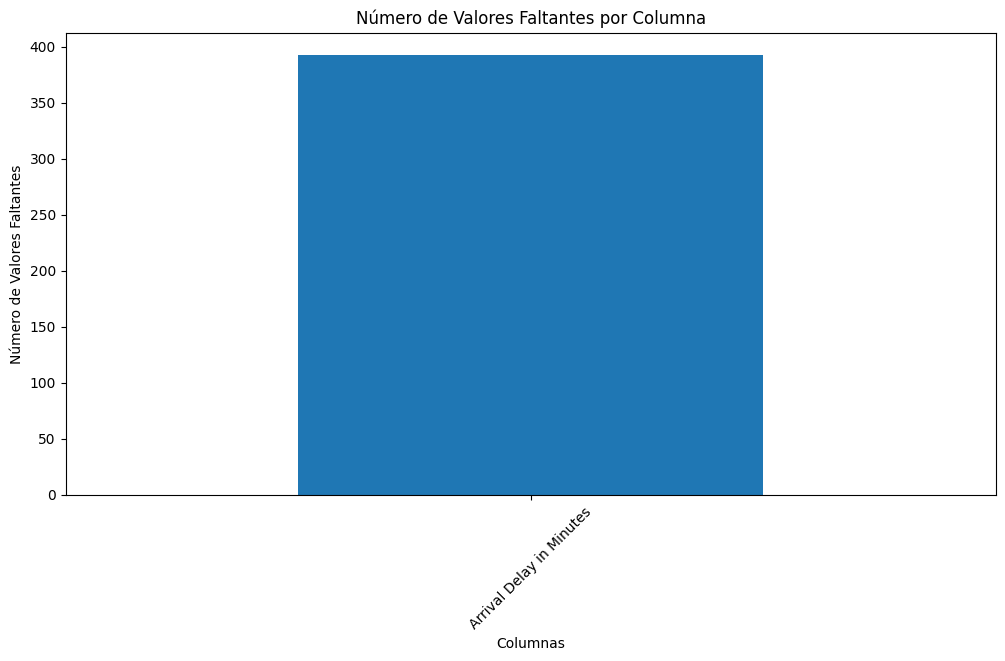

In [15]:
# Contar los valores nulos en cada columna
missing_values = data.isnull().sum()
missing_values = missing_values[missing_values > 0]

# Gráfico de barras de valores faltantes
plt.figure(figsize=(12, 6))
missing_values.plot(kind='bar')
plt.title('Número de Valores Faltantes por Columna')
plt.xlabel('Columnas')
plt.ylabel('Número de Valores Faltantes')
plt.xticks(rotation=45)
plt.show()

5. Distribución de Variables

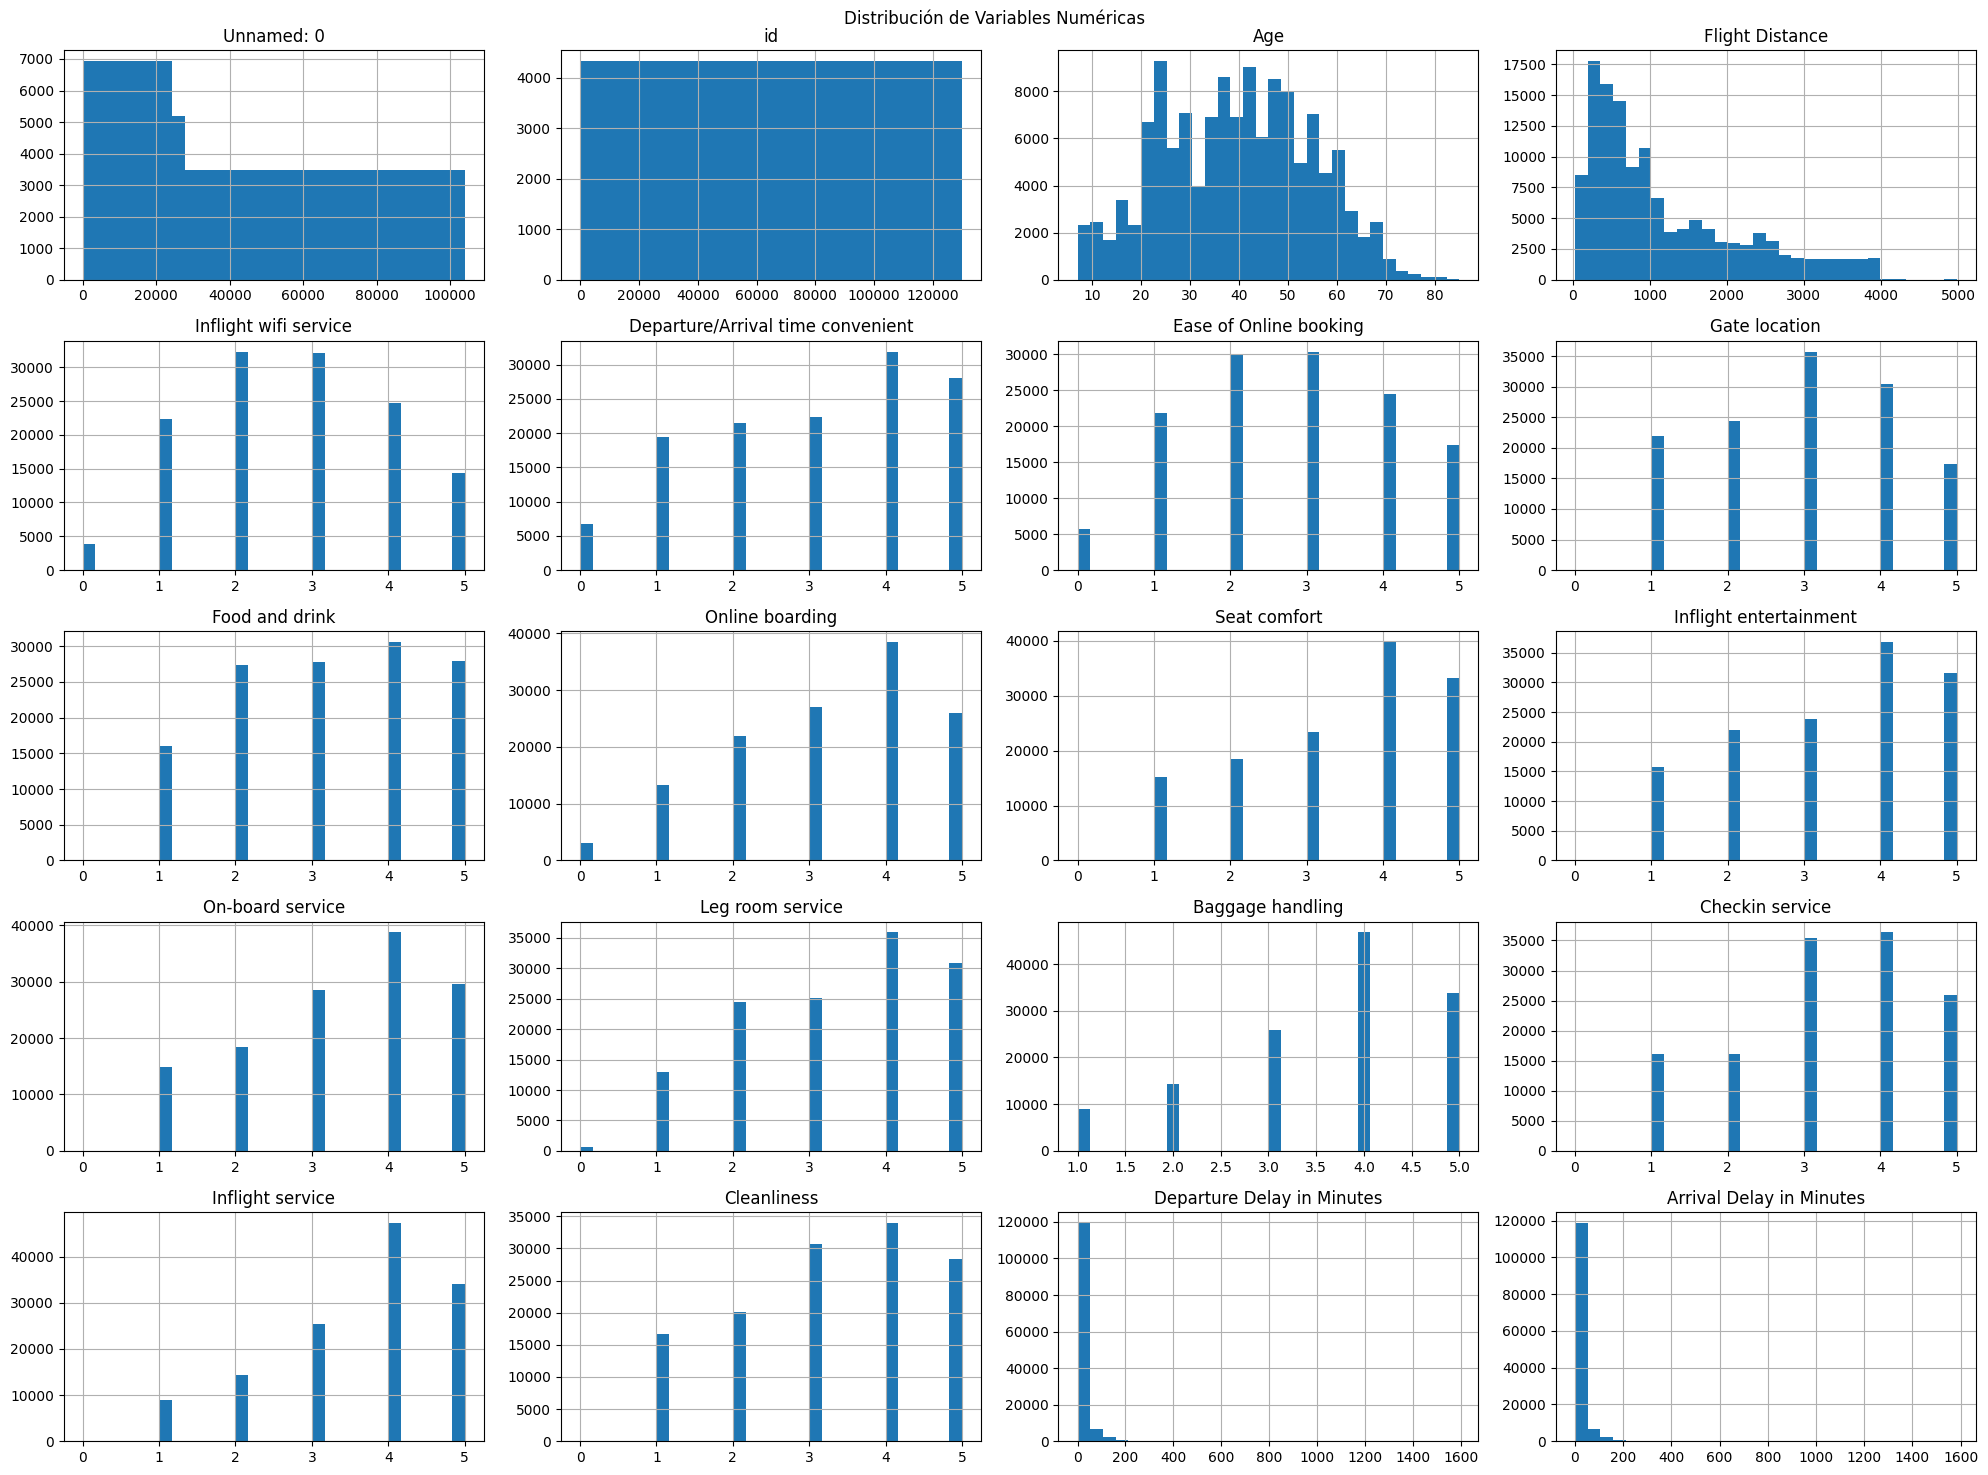

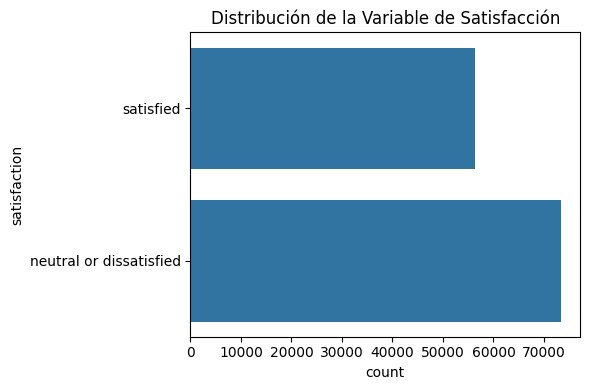

In [16]:
# Distribución de variables numéricas
data.hist(bins=30, figsize=(20, 15))
plt.suptitle('Distribución de Variables Numéricas')
plt.tight_layout()
plt.show()

# Distribución de variables categóricas
plt.figure(figsize=(6, 4))
sns.countplot(data['satisfaction'])
plt.title('Distribución de la Variable de Satisfacción')
plt.tight_layout()
plt.show()


6. Detección de Valores Atípicos (Outliers)

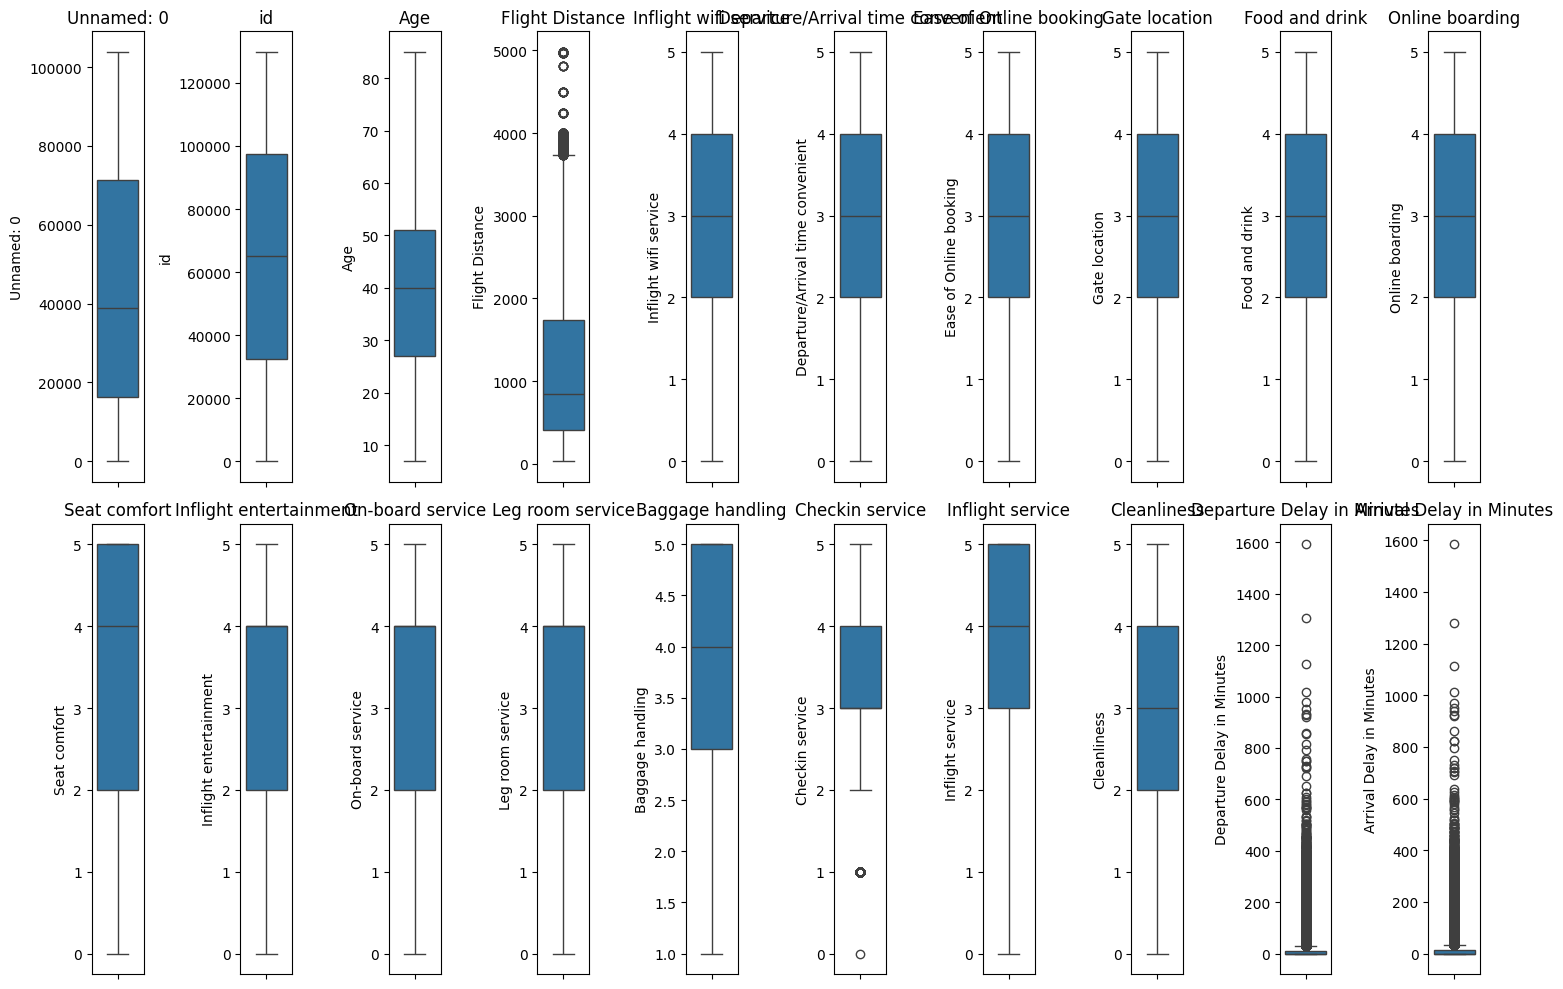

In [28]:
# Seleccionamos las columnas numéricas para visualización
num_columns = data.select_dtypes(include=[np.number]).columns

# Creamos subplots de boxplots para cada columna numérica
plt.figure(figsize=(15, 10))  # Ajustamos el tamaño de la figura

# Crear un boxplot para cada columna numérica
for i, column in enumerate(num_columns, 1):
    plt.subplot(2, (len(num_columns) + 1) // 2, i) # Ajustamos la cuadrícula para tener suficiente espacio
    sns.boxplot(y=data[column])
    plt.title(column)

plt.tight_layout() # Ajustamos el layout para evitar superposiciones
plt.show()

7. Análisis de Correlación

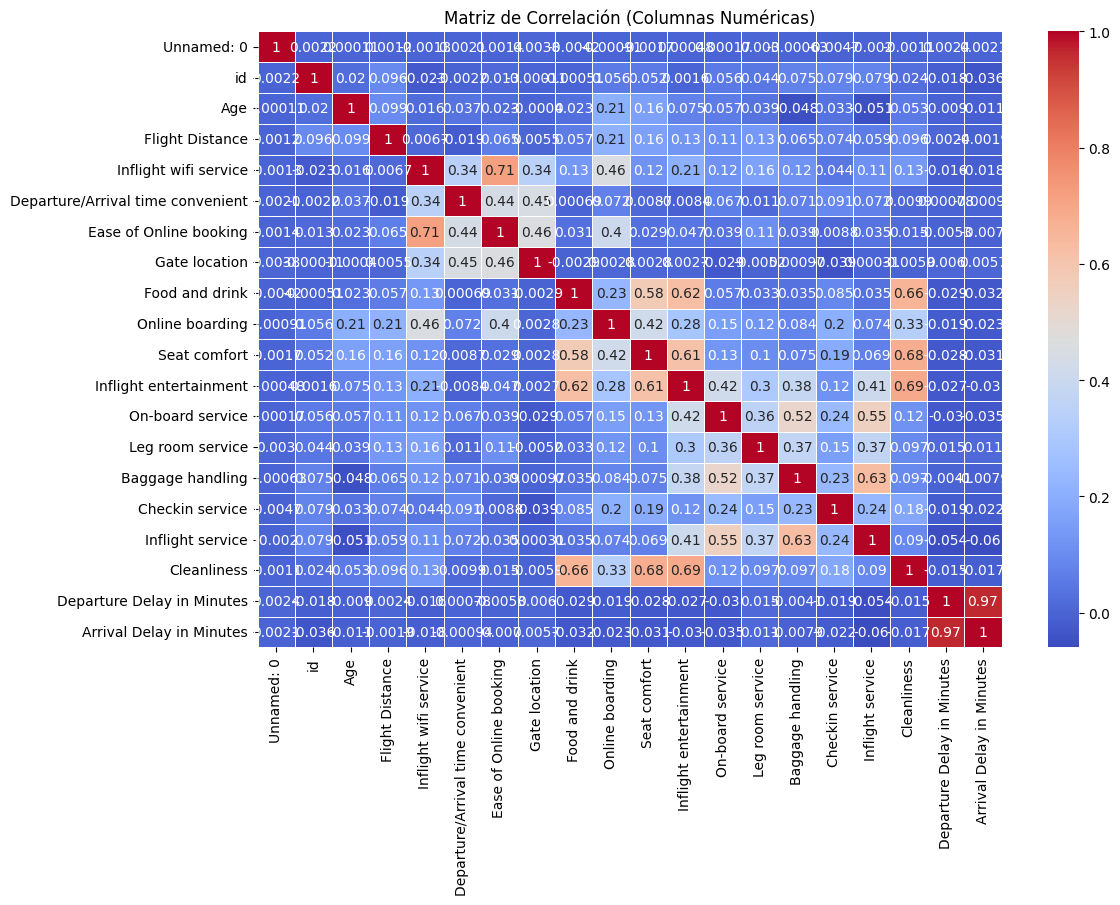

In [19]:
# Seleccionar solo columnas numéricas
num_columns = data.select_dtypes(include=[np.number])

# Matriz de correlación
plt.figure(figsize=(12, 8))
correlation_matrix = num_columns.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de Correlación (Columnas Numéricas)')
plt.show()